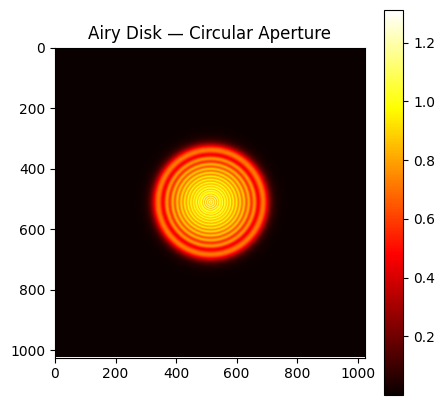

In [4]:
from LightPipes import *
import matplotlib.pyplot as plt
import numpy as np

wavelength = 632e-9
size = 10e-3
N = 1024

F = Begin(size, wavelength, N)
F = GaussBeam(F, 3e-3)

# Circular aperture
F = CircAperture(F, 2e-3)

# দূরে propagate করো
F = Forvard(F, 200e-3)

plt.figure(figsize=(5,5))
plt.imshow(Intensity(F), cmap='hot')
plt.title("Airy Disk — Circular Aperture")
plt.colorbar()
plt.show()

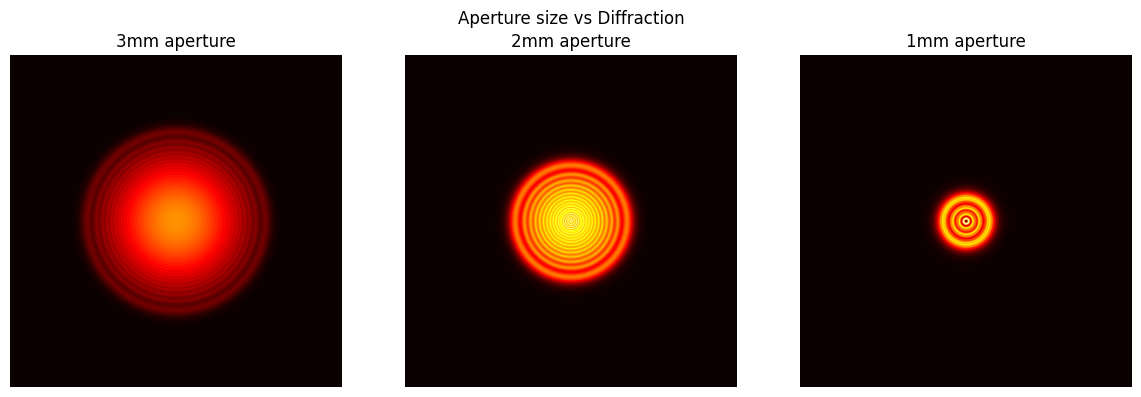

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
apertures = [3e-3, 2e-3, 1e-3]
titles = ['3mm aperture', '2mm aperture', '1mm aperture']

for i, ap in enumerate(apertures):
    F = Begin(size, wavelength, N)
    F = GaussBeam(F, 3e-3)
    F = CircAperture(F, ap)
    F = Forvard(F, 200e-3)
    axes[i].imshow(Intensity(F), cmap='hot')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.suptitle("Aperture size vs Diffraction")
plt.tight_layout()
plt.show()

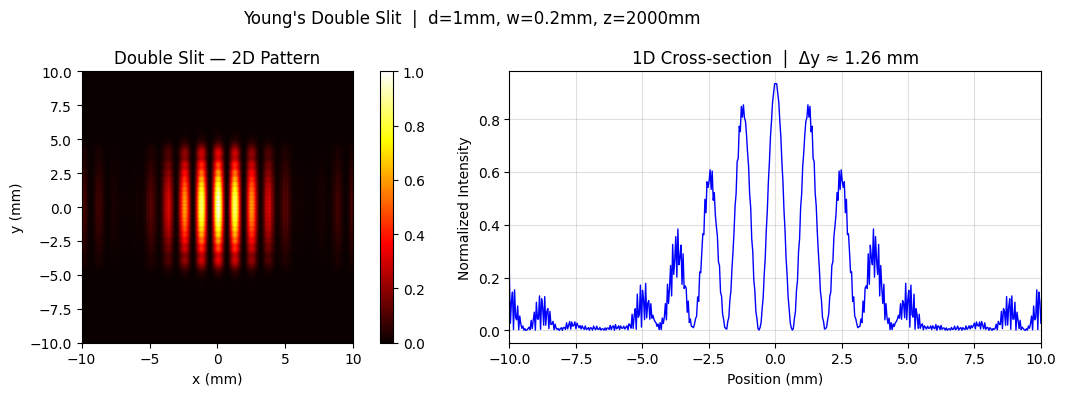

In [10]:
from LightPipes import *
import matplotlib.pyplot as plt
import numpy as np

wavelength = 632e-9
size = 20e-3      # বড় grid — pattern ধরতে
N = 512

# slit separation কমাও → কম দূরত্বে overlap হবে
d = 1e-3          # 1mm separation (আগে ছিল 3mm)
w = 0.2e-3        # slit width 0.2mm

F1 = Begin(size, wavelength, N)
F1 = GaussBeam(F1, 5e-3)
F1 = RectAperture(F1, w, 10e-3, x_shift=-d/2)

F2 = Begin(size, wavelength, N)
F2 = GaussBeam(F2, 5e-3)
F2 = RectAperture(F2, w, 10e-3, x_shift=+d/2)

F = BeamMix(F1, F2)
F = Forvard(F, 2000e-3)   # 2 meter — far field

I = Intensity(F)
I_norm = I / I.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(I_norm, cmap='hot', extent=[-10,10,-10,10],
                    vmin=0, vmax=1, origin='lower')
plt.colorbar(im, ax=axes[0])
axes[0].set_title("Double Slit — 2D Pattern")
axes[0].set_xlabel("x (mm)")
axes[0].set_ylabel("y (mm)")

x_axis = np.linspace(-size/2, size/2, N) * 1e3
axes[1].plot(x_axis, I_norm[N//2, :], color='blue', linewidth=1)
axes[1].set_title("Double Slit — 1D Cross-section")
axes[1].set_xlabel("Position (mm)")
axes[1].set_ylabel("Normalized Intensity")
axes[1].grid(True, alpha=0.4)
axes[1].set_xlim(-10, 10)

fringe_spacing = wavelength * 2.0 / d * 1e3
axes[1].set_title(f"1D Cross-section  |  Δy ≈ {fringe_spacing:.2f} mm")

plt.suptitle(f"Young's Double Slit  |  d={d*1e3:.0f}mm, w={w*1e3:.1f}mm, z=2000mm")
plt.tight_layout()
plt.show()